In [76]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os

Versions for libraries imported 

In [77]:
print(np.__version__)
print(matplotlib.__version__)
print(pd.__version__)


1.26.4
3.10.6
2.3.3


In [105]:
FourVehicleFolder="4Vehicle"
EightVehicleFolder="8Vehicle"
TwleveVehicleFolder="12Vehicle"
QUICDataFolder="QUICcsv"
TCPDataFolder="TCPcsv"
CombinedDataOutputFolder='CombinedData'
QUICCSVFiles=[]
TCPCSVFiles=[]
NumOfTrials=5
NumOfIndexs=6
NumOfPERValues=6
#Constants
VEHICLEINDEX=0
PERINDEX=1
AVGDELAYINDEX=2
P95INDEX=3
JITTERINDEX=4
GOODPUTINDEX=5

In [88]:
try:
    os.mkdir(CombinedDataOutputFolder)
except:
    print("error making folder")

error making folder


In [106]:
try:
    QUICCSVFiles=os.listdir(QUICDataFolder+"/"+FourVehicleFolder)
    TCPCSVFiles=os.listdir(TCPDataFolder+"/"+FourVehicleFolder)
    print(QUICCSVFiles)
    print(TCPCSVFiles)
except:
    print("couldn't open folder")

['4_4_Cars_Data_QUIC.csv', '5_4_Cars_Data_QUIC.csv', '1_4_Cars_Data_QUIC.csv', '6_4_Cars_Data_QUIC.csv', '3_4_Cars_Data_QUIC.csv']
['5_4_Cars_Data_TCP.csv', '6_4_Cars_Data_TCP.csv', '3_4_Cars_Data_TCP.csv', '4_4_Cars_Data_TCP.csv', '1_4_Cars_Data_TCP.csv']


In [107]:
print(QUICCSVFiles[1])

5_4_Cars_Data_QUIC.csv


In [160]:
QUICarray=np.zeros(shape=(NumOfTrials,NumOfPERValues,NumOfIndexs))
TCParray=np.zeros(shape=(NumOfTrials,NumOfPERValues,NumOfIndexs))
for i in range(0,NumOfTrials):
    QUICarray[i]=np.loadtxt(QUICDataFolder+"/"+FourVehicleFolder+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
    TCParray[i]=np.loadtxt(TCPDataFolder+"/"+FourVehicleFolder+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)



AverageQUICResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
AverageTCPResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
MedianQUICResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
MedianTCPResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
for i in range(0,NumOfIndexs):
    for j in range(0,NumOfPERValues):
        AverageQUICResults[j,i]=np.average(QUICarray[0:,j,i])
        AverageTCPResults[j,i]=np.average(TCParray[0:,j,i])
        MedianQUICResults[j,i]=np.median(QUICarray[0:,j,i])
        MedianTCPResults[j,i]=np.median(TCParray[0:,j,i])

In [141]:
# Source - https://stackoverflow.com/a/58106536
# Posted by Dennis Golomazov, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-25, License - CC BY-SA 4.0

import numpy as np

def format_float(num):
    return np.format_float_positional(num, precision=1, trim='-')


In [146]:
for i in range(0,NumOfPERValues):
    AverageQUICResults[i,VEHICLEINDEX]=format_float(AverageQUICResults[i,VEHICLEINDEX])
    AverageTCPResults[i,VEHICLEINDEX]=format_float(AverageTCPResults[i,VEHICLEINDEX])


In [161]:
print(AverageQUICResults)
CombinedFileName="Combined4.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,AverageTCPResults,delimiter=',')


[[4.0000000e+00 0.0000000e+00 4.5619920e+01 1.5490734e+02 7.7036620e+00
  9.3019780e-01]
 [4.0000000e+00 5.0000000e-03 2.1757720e+01 3.2891440e+01 7.1324340e+00
  9.6576360e-01]
 [4.0000000e+00 1.0000000e-02 3.1088420e+01 8.4359380e+01 7.5011380e+00
  9.6194880e-01]
 [4.0000000e+00 2.0000000e-02 4.6539900e+01 9.9384400e+01 7.8367400e+00
  9.5876760e-01]
 [4.0000000e+00 5.0000000e-02 4.0987600e+01 1.1671574e+02 8.8504420e+00
  9.1086760e-01]
 [4.0000000e+00 1.0000000e-01 4.7972200e+01 1.2312974e+02 1.0384346e+01
  8.6038220e-01]]


In [151]:
def PlotQUICVsTCP(QUICArray,TCPArray,Title,XLabel,YLabel):
    plt.plot(QUICArray[0:,0],QUICArray[0:,1],label="QUIC")
    plt.plot(TCPArray[0:,0],TCPArray[0:,1],label="TCP")
    plt.legend()
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()

Average results


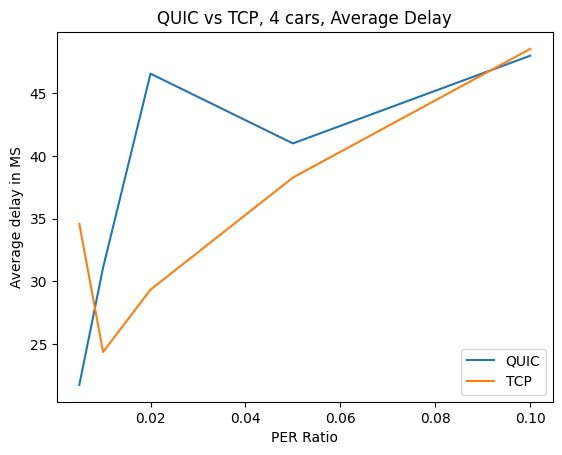

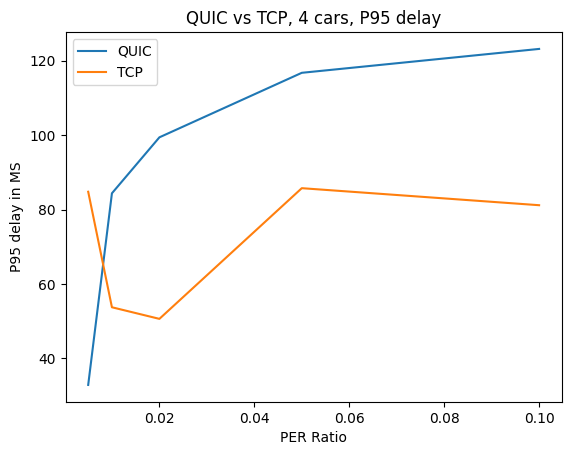

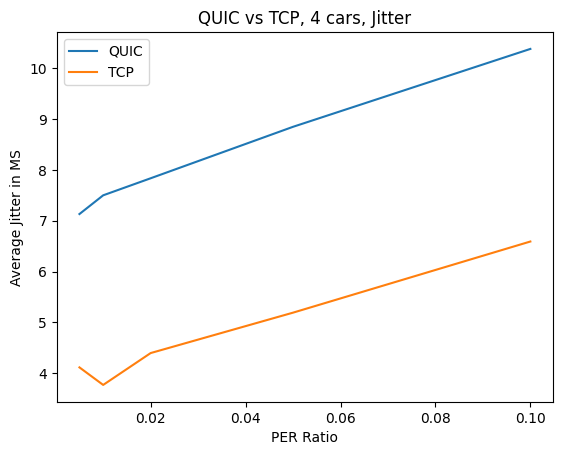

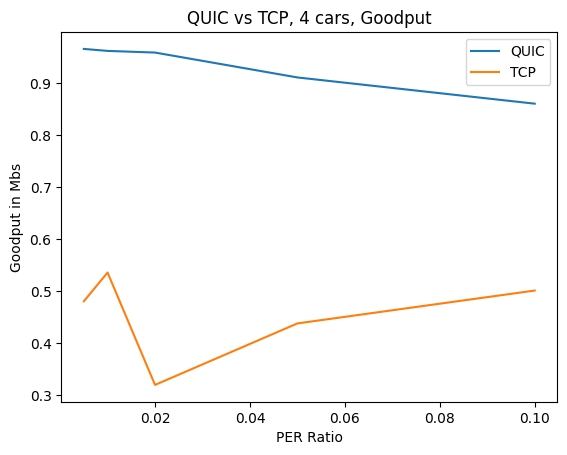

In [162]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 4 cars, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 4 cars, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 4 cars, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 4 cars, Goodput","PER Ratio","Goodput in Mbs")

In [ ]:
print(AverageQUICResults)
CombinedFileName="Combined4.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,MedianTCPResults,delimiter=',')

In [ ]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 4 cars, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 4 cars, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 4 cars, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 4 cars, Goodput","PER Ratio","Goodput in Mbs")


Median results
(6, 6)
[[4.00000e+00 0.00000e+00 4.73606e+01 1.46056e+02 7.98598e+00 9.39494e-01]
 [4.00000e+00 5.00000e-03 2.14067e+01 2.93545e+01 6.90674e+00 9.55901e-01]
 [4.00000e+00 1.00000e-02 2.32930e+01 3.80892e+01 7.06767e+00 9.59560e-01]
 [4.00000e+00 2.00000e-02 2.95523e+01 5.30259e+01 8.01763e+00 9.50026e-01]
 [4.00000e+00 5.00000e-02 2.64722e+01 5.92660e+01 8.73838e+00 9.06706e-01]
 [4.00000e+00 1.00000e-01 3.13164e+01 5.89362e+01 1.04278e+01 8.34620e-01]]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed